# EDA Notebook

### What data do I have?

###  Is the label usable?

###  Is the text usable?

### Which subset should I model first?

###  Are there obvious quality problems?

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("../data/raw/folk_tales.csv")
df = pd.read_csv(data_path)

In [118]:
# Basic exploration of the dataset
print('*' * 80)
print(df.head(3))
print('*' * 80)
df.info()
print('*' * 80)
print(df.shape)
print('*' * 80)
print(df.columns)
print('*' * 80)

********************************************************************************
                                       source url    nation  \
0                https://fairytalez.com/momotaro/  japanese   
1         https://fairytalez.com/the-birdcatcher/   serbian   
2  https://fairytalez.com/sharing-joy-and-sorrow/    german   

                    title                                               text  
0                Momotaro  If you’ll believe me there was a time when the...  
1         The Birdcatcher  Near Constantinople there lived a man who knew...  
2  Sharing Joy and Sorrow  There was once a tailor, who was a quarrelsome...  
********************************************************************************
<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   source url  2938 non-null   str  
 1   nation      2932 non-null   str  
 2   title       2

In [119]:
#Standardize Column Name
df.columns = (df.columns.str.strip().str.lower().str.replace(' ', '_'))
df.columns

Index(['source_url', 'nation', 'title', 'text'], dtype='str')

In [120]:
#Check missing values
print(df.isnull().sum())
df = df.dropna(subset=["nation", "text"]).copy()


source_url    0
nation        6
title         0
text          0
dtype: int64


In [121]:
#Clean whitespace
df["nation"] = df["nation"].astype(str).str.strip()
df["text"] = df["text"].astype(str).str.strip()
df["title"] = df["title"].astype(str).str.strip()
df["source_url"] = df["source_url"].astype(str).str.strip()

In [122]:
#Check Empty Strings
for col in ["source_url", "nation", "title", "text"]:
    empty_count = (df[col] == "").sum()
    print(col, empty_count)

df = df[(df["nation"] != "") & (df["text"] != "")].copy()

source_url 0
nation 0
title 0
text 0


In [123]:
#Remove duplicates
df.duplicated().sum()

before = df.shape[0]

df = df.drop_duplicates(subset=["text"]).copy()

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Duplicate stories removed:", before - after)

Rows before: 2932
Rows after: 2929
Duplicate stories removed: 3


## Analyse

In [124]:
nation_counts = df["nation"].value_counts()
nation_counts

nation
north_american_native    370
greek                    304
german                   277
french                   168
indian                   130
english                  120
italian                  104
chinese                  101
japanese                  88
nordic                    85
russian                   80
scandinavian              72
philippine                72
irish                     60
portuguese                55
danish                    51
australian_ethnic         48
czechoslovak              46
slavic                    44
scottish                  43
arabic                    41
celtic                    40
nigerian                  39
brazilian                 31
armenian                  31
swedish                   31
ukrainian                 27
norwegian                 26
albanian                  25
polish                    24
south_african             24
dutch                     22
welsh                     18
romanian                  18
serbian

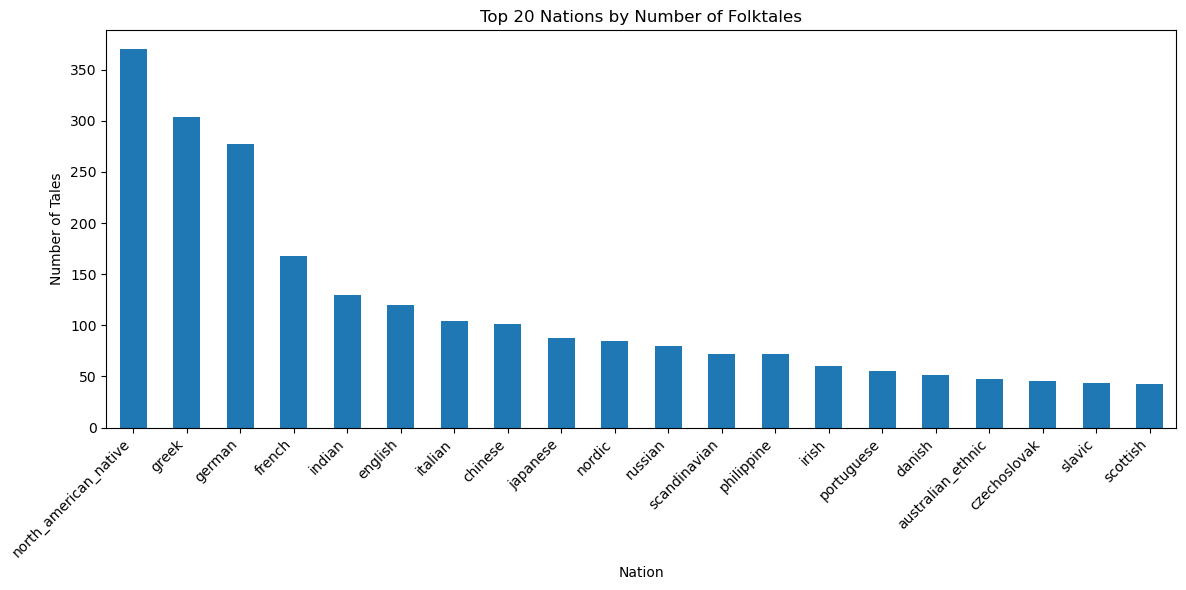

In [125]:
plt.figure(figsize=(12, 6))
nation_counts.head(20).plot(kind="bar")
plt.title("Top 20 Nations by Number of Folktales")
plt.xlabel("Nation")
plt.ylabel("Number of Tales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [126]:
# Custom feature Text Length
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df[["char_count", "word_count"]].describe()

,char_count,word_count
count,2929.000000,2929.000000
mean,9024.434961,1688.981905
std,9446.159325,1758.853406
min,130.000000,20.000000
25%,2554.000000,482.000000
50%,6387.000000,1191.000000
75%,12200.000000,2297.000000
max,106121.000000,19215.000000


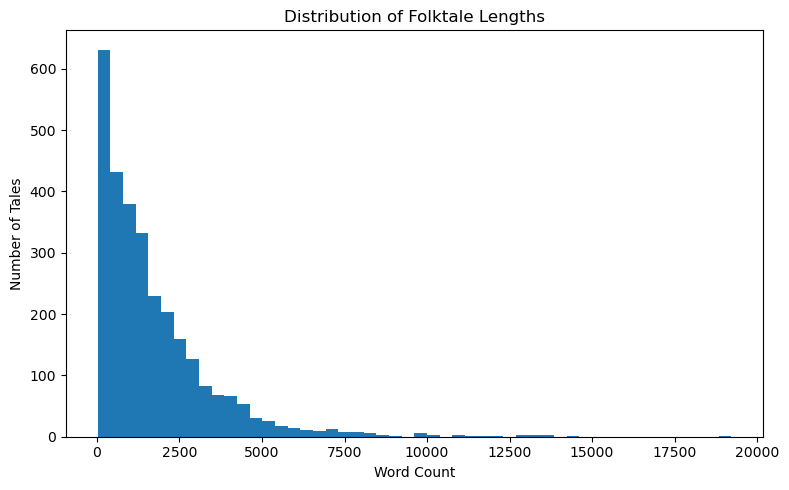

In [127]:
plt.figure(figsize=(8, 5))
df["word_count"].plot(kind="hist", bins=50)
plt.title("Distribution of Folktale Lengths")
plt.xlabel("Word Count")
plt.ylabel("Number of Tales")
plt.tight_layout()
plt.show()

## Dataset for v1

In [129]:
nation_counts = df["nation"].value_counts()

selected_nations = nation_counts[nation_counts >= 100].index

df_model = df[df["nation"].isin(selected_nations)].copy()

df_model["nation"].value_counts()

nation
north_american_native    370
greek                    304
german                   277
french                   168
indian                   130
english                  120
italian                  104
chinese                  101
Name: count, dtype: int64

In [132]:
df_model["clean_text"] = (
    df_model["text"]
    .str.lower()
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [133]:
output_path = Path("../data/processed/folktales_model_ready.csv")

df_model.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../data/processed/folktales_model_ready.csv
